# commavq Testing Approach & Exploration

This notebook demonstrates the testing approaches used in the `commavq` repository.

## Test Approach
We utilize a combination of **Bottom-Up** and **End-to-End** testing methodologies.
- **Bottom-Up**: We test individual components like `ResnetBlock` and `AttnBlock` in isolation to ensure that they maintain shape invariants and correctly apply their mathematical operations.
- **End-to-End**: We test the entire decoding pipeline by decoding known, compressed driving tokens back into visual frames, and mathematically verifying their visual similarity (SSIM) to the original video frames.


## Bottom Up Testing: Model Blocks
In this section, we instantiate a `ResnetBlock` and demonstrate that passing a tensor through it yields a tensor of the same shape, which is the primary invariant tested in `test_resnet_block.py`.


In [7]:
import torch
import sys
from pathlib import Path

# Robustly find repository root regardless of whether run in VS Code or Jupyter browser
current_dir = Path.cwd()
if (current_dir / "utils" / "vqvae.py").exists():
    REPO_ROOT = current_dir.resolve()
else:
    REPO_ROOT = current_dir.parent.resolve()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.vqvae import ResnetBlock

print("Initializing ResnetBlock...")
block = ResnetBlock(in_channels=128, out_channels=128, temb_channels=0, dropout=0.0)

# Create a dummy feature map (Batch=2, Channels=128, H=16, W=16)
dummy_input = torch.randn(2, 128, 16, 16)
print(f"Input shape:  {dummy_input.shape}")

# Pass through the block
output = block(dummy_input, temb=None)
print(f"Output shape: {output.shape}")

assert dummy_input.shape == output.shape
print("Shape invariant maintained.")


Initializing ResnetBlock...
Input shape:  torch.Size([2, 128, 16, 16])
Output shape: torch.Size([2, 128, 16, 16])
Shape invariant maintained.


## End-to-End Testing: Round Trip SSIM
Here we run the actual `test_roundtrip_ssim.py` script. This script loads `examples/tokens.npy`, decodes them using the pretrained Decoder, and compares the output to the `examples/sample_video_ecamera.hevc` video. It asserts that the mean Structural Similarity Index (SSIM) is above `0.6`. It also generates an image file `roundtrip_decoded.png` with the decoded frames.


Running round trip test script...
================================================= test session starts =================================================
platform win32 -- Python 3.13.4, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\johns\OneDrive\Documents\OU\Classes\Spring 2026\CS-4223-001-software-quality-testing\ticket2\commavq\venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\johns\OneDrive\Documents\OU\Classes\Spring 2026\CS-4223-001-software-quality-testing\ticket2\commavq
plugins: anyio-4.13.0, cov-7.1.0
collecting ... collected 1 item

tests/test_roundtrip_ssim.py::test_roundtrip_ssim_above_threshold PASSED                                         [100%]

================================================= 1 passed in 24.55s ==================================================

Displaying the generated frames:


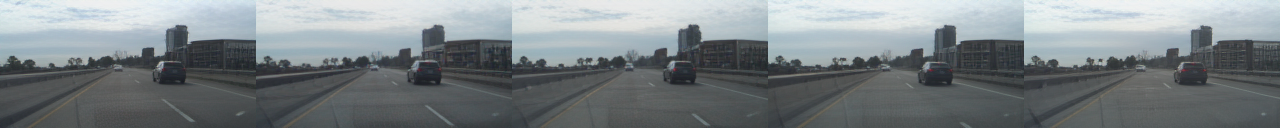

In [3]:
import subprocess
import sys
from IPython.display import display
from PIL import Image

print("Running round trip test script...")
# We use sys.executable to ensure we run pytest from the exact same python environment the kernel is using
result = subprocess.run([sys.executable, "-m", "pytest", "tests/test_roundtrip_ssim.py", "-v"], cwd=str(REPO_ROOT), capture_output=True, text=True)
print(result.stdout)

image_path = REPO_ROOT / "roundtrip_decoded.png"
if image_path.exists():
    print("Displaying the generated frames:")
    display(Image.open(image_path))
else:
    print("Image not found. Make sure the test passed and generated the file.")


## Degradation Experiment
To prove that our SSIM threshold catches bad decoder outputs, let us intentionally degrade the model by modifying `utils/vqvae.py`. We will comment out the `post_quant_conv` step in the decoder, and rerun the round trip test. We expect the test to fail.


Running round trip test with degraded model...
Test Output (showing failure):
      # decoded is (NUM_FRAMES, 3, 128, 256) float; convert to (N, H, W, C) uint8.
      decoded = transpose_and_clip(decoded)
      assert decoded.shape == source_frames.shape
    
      from PIL import Image
      grid = np.concatenate(decoded, axis=1)
      Image.fromarray(grid).save(str(REPO_ROOT / "roundtrip_decoded.png"))
    
      # Per-frame SSIM, averaged over the batch. channel_axis=-1 treats the RGB
      # channels jointly (one SSIM per frame, not per channel).
      ssims = [
        skimage.structural_similarity(
          source_frames[i], decoded[i], channel_axis=-1, data_range=255
        )
        for i in range(NUM_FRAMES)
      ]
      mean_ssim = float(np.mean(ssims))
    
>     assert mean_ssim >= SSIM_THRESHOLD, (
        f"round-trip SSIM {mean_ssim:.3f} below threshold {SSIM_THRESHOLD}; "
        f"per-frame: {[round(s, 3) for s in ssims]}"
      )
E     AssertionError: round-trip SS

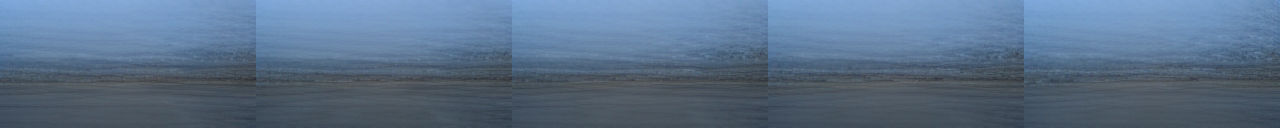

Reverting utils/vqvae.py back to original state.


In [4]:
vqvae_file = REPO_ROOT / "utils" / "vqvae.py"
with open(vqvae_file, "r") as f:
    original_code = f.read()

# Comment out the post_quant_conv block to heavily degrade the image
modified_code = original_code.replace("z = self.post_quant_conv(z)", "# z = self.post_quant_conv(z)")

with open(vqvae_file, "w") as f:
    f.write(modified_code)

try:
    print("Running round trip test with degraded model...")
    result = subprocess.run([sys.executable, "-m", "pytest", "tests/test_roundtrip_ssim.py", "-v"], cwd=str(REPO_ROOT), capture_output=True, text=True)
    print("Test Output (showing failure):")
    
    # We only print the tail end to avoid too much noise
    lines = result.stdout.split("\n")
    start_index = max(0, len(lines) - 30)
    print("\n".join(lines[start_index:]))

    image_path = REPO_ROOT / "roundtrip_decoded.png"
    if image_path.exists():
        print("\nDisplaying the degraded frames:")
        display(Image.open(image_path))
    else:
        print("Degraded image not found.")
finally:
    # Revert the changes
    print("Reverting utils/vqvae.py back to original state.")
    with open(vqvae_file, "w") as f:
        f.write(original_code)


## Test Coverage
Finally, let us run our test suite using `pytest` and generate a coverage report for our `utils.vqvae` module to see how much of our code is exercised by the tests.


In [5]:
import IPython.display
import subprocess
import os
import webbrowser

print("Running coverage script...")
# We use subprocess so we can cleanly capture output
result = subprocess.run(["powershell", "-File", "./scripts/run_coverage.ps1"], cwd=str(REPO_ROOT), capture_output=True, text=True)

# Print a summary of the coverage
lines = result.stdout.split("\n")
for line in lines:
    if "utils\\vqvae" in line or "TOTAL" in line or "coverage:" in line:
        print(line)

# Serve the HTML report over a local HTTP server so VS Code opens it in a real browser
html_dir = REPO_ROOT / "tests" / "coverage_report_html"
if html_dir.exists():
    import threading
    import http.server
    import socketserver
    import socket

    # Create a handler serving the specific directory
    class Handler(http.server.SimpleHTTPRequestHandler):
        def __init__(self, *args, **kwargs):
            super().__init__(*args, directory=str(html_dir), **kwargs)
            
    # Find a free port
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.bind(('', 0))
    port = s.getsockname()[1]
    s.close()

    # Start server in a background thread
    httpd = socketserver.TCPServer(("", port), Handler)
    thread = threading.Thread(target=httpd.serve_forever, daemon=True)
    thread.start()

    print(f"\nLocal server started on port {port}.")
    display(IPython.display.HTML(f"<a href='http://localhost:{port}/index.html' target='_blank'><b>Click here to open the HTML Coverage Report in your Web Browser</b></a>"))
else:
    print("HTML report not found.")


Running coverage script...
___________________________________ coverage: platform win32, python 3.13.4-final-0 ___________________________________
utils\vqvae.py     247      0   100%
TOTAL              247      0   100%

Local server started on port 51225.
